# Support Vector Machines (SVMs)

## Real-World Scenario: Classifying Bacterial Cells as Stressed vs. Normal

In whole cell modeling, we often need to label single cells based on a few measured biomarkers — for instance, classifying *E. coli* cells as **stressed** or **normal** from two stress-response proteins (RpoS and DnaK). Many cells are clearly one or the other, but a handful sit in an ambiguous overlap region. We want a classifier that:

1. Picks the **most robust** decision boundary (large margin), so it generalizes to new cells
2. Tolerates a **few violations** (some cells will always be misclassified, and that's OK)
3. Can capture **nonlinear** boundaries (real biology rarely separates linearly)

The **Support Vector Machine** (SVM) does exactly this. It's a non-probabilistic predictor of the form

$$f(\mathbf{x}) = \sum_{i=1}^{N} \alpha_i\, \kappa(\mathbf{x}, \mathbf{x}_i) + w_0$$

where most $\alpha_i = 0$, so predictions only depend on a sparse subset of training points — the **support vectors**. We will derive everything from scratch:

1. **Large-margin classifier** (§17.3.1) — geometric intuition and the primal QP
2. **Dual problem** (§17.3.2) — Lagrangian, KKT, and how support vectors emerge
3. **Soft margin** (§17.3.3) — slack variables and the regularizer $C$
4. **Kernel trick** (§17.3.4) — nonlinear boundaries with RBF kernels
5. **Probabilistic outputs** (§17.3.5) — Platt scaling and its limitations
6. **Hinge loss view** (§17.3.6) — connection to logistic regression
7. **Multi-class** (§17.3.7) — one-vs-rest and one-vs-one
8. **Choosing $C$ and $\gamma$** (§17.3.8) — cross-validation grid
9. **SVM regression** (§17.3.10) — $\epsilon$-insensitive loss for sparse regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap
from scipy.optimize import minimize
from scipy.spatial.distance import cdist

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## Key Formulas from PML Chapter 17.3

**Primal (hard margin)** (Eq. 17.68):
$$\min_{\mathbf{w}, w_0}\; \tfrac{1}{2}\|\mathbf{w}\|^2 \quad \text{s.t.}\quad \tilde y_n(\mathbf{w}^\top \mathbf{x}_n + w_0) \geq 1,\; n=1{:}N$$

**Dual (hard margin)** (Eq. 17.77):
$$\max_{\boldsymbol{\alpha}}\; \sum_n \alpha_n - \tfrac{1}{2}\sum_{i,j} \alpha_i \alpha_j\, \tilde y_i \tilde y_j\, \mathbf{x}_i^\top \mathbf{x}_j$$
$$\text{s.t.}\quad \sum_n \alpha_n \tilde y_n = 0,\; \alpha_n \geq 0$$

**Recovering primal weights** (Eq. 17.73):
$$\hat{\mathbf{w}} = \sum_{n=1}^N \hat\alpha_n\, \tilde y_n\, \mathbf{x}_n$$

**KKT conditions** (Eq. 17.78–17.80) — only support vectors have $\alpha_n > 0$.

**Soft margin** (Eq. 17.83):
$$\min_{\mathbf{w}, w_0, \boldsymbol{\xi}}\; \tfrac{1}{2}\|\mathbf{w}\|^2 + C \sum_n \xi_n \;\;\text{s.t.}\;\; \xi_n \geq 0,\; \tilde y_n(\mathbf{w}^\top \mathbf{x}_n + w_0) \geq 1 - \xi_n$$

The dual is identical to the hard margin case but with $0 \leq \alpha_n \leq C$ (Eq. 17.86).

**Kernel trick — prediction** (Eq. 17.93):
$$f(\mathbf{x}) = \sum_{n \in \mathcal{S}} \alpha_n\, \tilde y_n\, \kappa(\mathbf{x}_n, \mathbf{x}) + \hat w_0$$

**Hinge loss** (Eq. 17.97): $\ell_{\text{hinge}}(\tilde y, \eta) = \max(0, 1 - \tilde y\eta)$.

**Platt scaling** (Eq. 17.95): $p(y=1|\mathbf{x}) = \sigma(a\,f(\mathbf{x}) + b)$.

**$\epsilon$-insensitive loss** (Eq. 17.110): $L_\epsilon(y, \hat y) = \max(0, |y-\hat y| - \epsilon)$.

## 1. Generate Synthetic Cell Stress Data

We simulate two protein expression measurements (RpoS, DnaK) for $N = 60$ *E. coli* cells. Two clusters: **normal** ($\tilde y = -1$) and **stressed** ($\tilde y = +1$). The clusters are linearly separable with a clear margin, so we can demonstrate the hard-margin SVM first.

X shape: (60, 2),  labels in {1, -1}
y = +1 (stressed): 30,  y = -1 (normal): 30


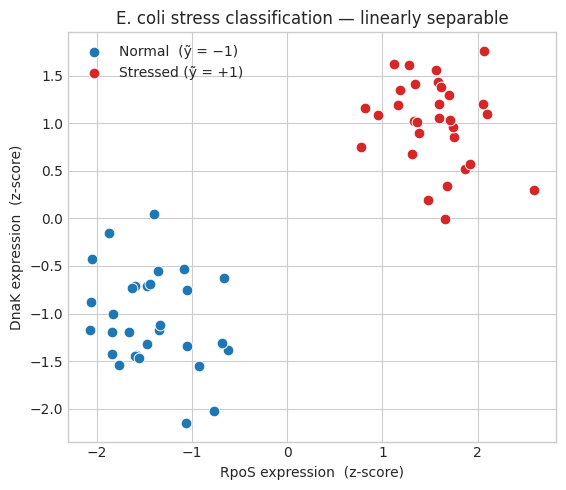

In [2]:
def make_separable_data(n_per_class=30, seed=0):
    rng = np.random.RandomState(seed)
    # Normal cells: low RpoS, low DnaK
    X_neg = rng.randn(n_per_class, 2) * 0.5 + np.array([-1.5, -1.0])
    # Stressed cells: high RpoS, high DnaK
    X_pos = rng.randn(n_per_class, 2) * 0.5 + np.array([ 1.5,  1.0])
    X = np.vstack([X_neg, X_pos])
    y = np.concatenate([-np.ones(n_per_class), np.ones(n_per_class)])
    perm = rng.permutation(len(y))
    return X[perm], y[perm]


X, y = make_separable_data(n_per_class=30, seed=1)
print(f'X shape: {X.shape},  labels in {set(y.astype(int))}')
print(f'y = +1 (stressed): {(y == +1).sum()},  y = -1 (normal): {(y == -1).sum()}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[y == -1, 0], X[y == -1, 1], c='#1f77b4', s=60, edgecolor='white',
           linewidth=0.7, label='Normal  (ỹ = −1)')
ax.scatter(X[y == +1, 0], X[y == +1, 1], c='#d62728', s=60, edgecolor='white',
           linewidth=0.7, label='Stressed (ỹ = +1)')
ax.set_xlabel('RpoS expression  (z-score)')
ax.set_ylabel('DnaK expression  (z-score)')
ax.set_title('E. coli stress classification — linearly separable')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 2. Large-Margin Classifier (§17.3.1) — The Geometry

We seek a hyperplane $f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} + w_0 = 0$ that separates the classes with **maximum margin**. The signed distance of point $\mathbf{x}$ to the boundary is $r = f(\mathbf{x})/\|\mathbf{w}\|$.

After rescaling so the closest point satisfies $\tilde y_n f_n = 1$ (Eq. 17.67), maximizing $1/\|\mathbf{w}\|$ becomes minimizing $\tfrac{1}{2}\|\mathbf{w}\|^2$ subject to $\tilde y_n(\mathbf{w}^\top \mathbf{x}_n + w_0) \geq 1$.

This is a convex **quadratic program**. We solve the **dual** form (Eq. 17.77):

$$\max_{\boldsymbol{\alpha}}\; \sum_n \alpha_n - \tfrac{1}{2}\boldsymbol{\alpha}^\top \mathbf{H} \boldsymbol{\alpha}, \qquad H_{ij} = \tilde y_i \tilde y_j\, \mathbf{x}_i^\top \mathbf{x}_j$$

with constraints $\sum_n \alpha_n \tilde y_n = 0$ and $\alpha_n \geq 0$.

In [3]:
def solve_svm_dual(X, y, C=None, kernel_matrix=None):
    """Solve the SVM dual QP using scipy.optimize.minimize (SLSQP).

    Parameters
    ----------
    X : (N, D) data matrix (used only if kernel_matrix is None)
    y : (N,)  labels in {-1, +1}
    C : upper bound on alpha_n.  None for hard margin (no upper bound).
    kernel_matrix : optional precomputed N×N Gram matrix; otherwise linear K = X X^T.

    Returns dict with alpha, w (if linear), w0, and indices of support vectors.
    """
    N = len(y)
    K = kernel_matrix if kernel_matrix is not None else X @ X.T   # Gram matrix

    # H_ij = y_i y_j K_ij — the Hessian of the dual quadratic
    H = (y[:, None] * y[None, :]) * K

    # Negate to minimize: -(sum alpha) + 0.5 alpha^T H alpha
    def neg_dual(alpha):
        return 0.5 * alpha @ H @ alpha - alpha.sum()

    def neg_dual_grad(alpha):
        return H @ alpha - np.ones(N)

    # Constraints: sum(alpha_n y_n) = 0
    constraints = [{'type': 'eq',
                    'fun': lambda a: a @ y,
                    'jac': lambda a: y}]

    # Box constraints on alpha
    upper = C if C is not None else None
    bounds = [(0.0, upper) for _ in range(N)]

    alpha0 = np.zeros(N)
    res = minimize(neg_dual, alpha0, jac=neg_dual_grad,
                   bounds=bounds, constraints=constraints,
                   method='SLSQP', options={'maxiter': 500, 'ftol': 1e-10})
    alpha = np.maximum(res.x, 0.0)

    # Support vectors: alpha > tiny threshold
    sv_mask = alpha > 1e-5
    sv_idx = np.where(sv_mask)[0]

    # Recover primal weights (Eq. 17.73) — only meaningful for linear kernel
    w = (alpha * y) @ X if kernel_matrix is None else None

    # Recover bias w0 by averaging over margin support vectors
    # For soft margin, "on-margin" SVs have 0 < alpha < C
    if C is None:
        margin_mask = sv_mask
    else:
        margin_mask = (alpha > 1e-5) & (alpha < C - 1e-5)
    if margin_mask.sum() == 0:
        margin_mask = sv_mask  # fallback: use all SVs
    # f(x_n) = sum_m alpha_m y_m K_mn   =>   w0 = y_n - f(x_n) for SVs on margin
    f_no_bias = (alpha * y) @ K
    w0 = float(np.mean(y[margin_mask] - f_no_bias[margin_mask]))

    return {'alpha': alpha, 'w': w, 'w0': w0, 'sv_idx': sv_idx,
            'sv_mask': sv_mask, 'margin_mask': margin_mask, 'success': res.success}


# Solve hard-margin SVM
result = solve_svm_dual(X, y, C=None)
alpha, w, w0 = result['alpha'], result['w'], result['w0']
sv_idx = result['sv_idx']

print(f'Solver succeeded: {result["success"]}')
print(f'Primal weights:   w = [{w[0]:.4f}, {w[1]:.4f}],   w0 = {w0:.4f}')
print(f'Margin width:     2/||w|| = {2 / np.linalg.norm(w):.4f}')
print(f'# support vectors: {len(sv_idx)} out of {len(y)}')
print(f'\nDual variables for support vectors:')
for i in sv_idx:
    print(f'  cell {i:2d}:  ỹ={int(y[i]):+d},  α={alpha[i]:.4f}')

Solver succeeded: True
Primal weights:   w = [0.7254, 0.6897],   w0 = -0.0801
Margin width:     2/||w|| = 1.9981
# support vectors: 2 out of 60

Dual variables for support vectors:
  cell 36:  ỹ=+1,  α=0.5010
  cell 58:  ỹ=-1,  α=0.5010


**Reading the output**: only a *handful* of cells — those right at the edge of the cluster — have $\alpha_i > 0$. These are the **support vectors**: the only training points that affect the decision boundary. Removing any non-SV would not change $\hat{\mathbf{w}}$ at all.

## 3. Visualizing the Decision Boundary, Margin, and Support Vectors

The boundary is the line $\mathbf{w}^\top \mathbf{x} + w_0 = 0$. The **margin** is the band between $\mathbf{w}^\top \mathbf{x} + w_0 = -1$ and $\mathbf{w}^\top \mathbf{x} + w_0 = +1$. Width = $2/\|\mathbf{w}\|$.

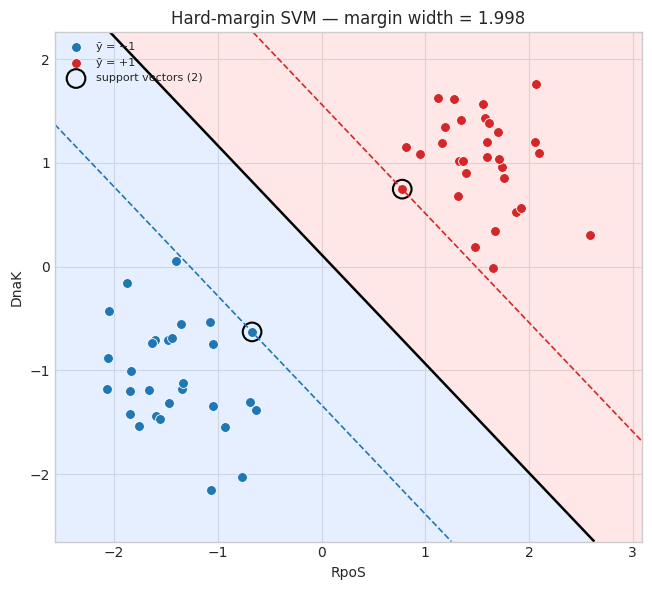

In [4]:
def plot_decision_boundary(X, y, predict_fn, ax, sv_idx=None,
                            title='', show_margin=True, score_levels=(-1, 0, 1)):
    """Plot data, decision regions, and (optionally) margin lines + SVs."""
    pad = 0.5
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict_fn(grid).reshape(xx.shape)

    # Filled regions
    cmap_bg = ListedColormap(['#cce0ff', '#ffd0d0'])
    ax.contourf(xx, yy, np.sign(Z), levels=[-2, 0, 2], cmap=cmap_bg, alpha=0.5)

    # Boundary + margin
    if show_margin:
        cs = ax.contour(xx, yy, Z, levels=list(score_levels),
                        colors=['#1f77b4', 'black', '#d62728'],
                        linestyles=['--', '-', '--'], linewidths=[1.2, 1.8, 1.2])

    # Data
    ax.scatter(X[y == -1, 0], X[y == -1, 1], c='#1f77b4', s=50,
               edgecolor='white', linewidth=0.6, label='ỹ = −1')
    ax.scatter(X[y == +1, 0], X[y == +1, 1], c='#d62728', s=50,
               edgecolor='white', linewidth=0.6, label='ỹ = +1')

    # Highlight support vectors
    if sv_idx is not None and len(sv_idx) > 0:
        ax.scatter(X[sv_idx, 0], X[sv_idx, 1], s=180, facecolors='none',
                   edgecolors='black', linewidth=1.5, label=f'support vectors ({len(sv_idx)})')

    ax.set_xlabel('RpoS')
    ax.set_ylabel('DnaK')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.legend(fontsize=8, loc='upper left')


def linear_predict(grid, w, w0):
    return grid @ w + w0


fig, ax = plt.subplots(figsize=(7, 6))
plot_decision_boundary(X, y, lambda g: linear_predict(g, w, w0), ax,
                        sv_idx=sv_idx,
                        title=f'Hard-margin SVM — margin width = {2/np.linalg.norm(w):.3f}')
plt.tight_layout()
plt.show()

**Notice**: the dashed lines (the margin boundaries $f = \pm 1$) **touch exactly the support vectors** — that's the KKT condition $\alpha_n(\tilde y_n f_n - 1) = 0$ in action. For non-SVs, $\alpha_n = 0$ and the constraint is inactive (they sit comfortably outside the margin).

## 4. Verifying KKT Conditions and Primal-Dual Equivalence

Three checks (Eq. 17.78–17.80):

1. $\alpha_n \geq 0$ for all $n$
2. $\tilde y_n f_n \geq 1$ for all $n$ (constraints satisfied)
3. $\alpha_n (\tilde y_n f_n - 1) = 0$ — either $\alpha = 0$ **or** the point is *on* the margin

We also verify the recovered weights satisfy $\hat{\mathbf{w}} = \sum_n \alpha_n \tilde y_n \mathbf{x}_n$.

In [5]:
# Compute f(x_n) = w^T x_n + w0 for all training points
f_train = X @ w + w0
margin_values = y * f_train   # should be >= 1, and = 1 for SVs

print('KKT check:')
print(f'  min α_n               = {alpha.min():.2e}    (should be ≥ 0)')
print(f'  min(ỹ_n f_n)          = {margin_values.min():.4f}  (should be ≥ 1)')
print(f'  max |α_n (ỹ_n f_n − 1)| = {np.max(np.abs(alpha * (margin_values - 1))):.2e}  (should be ≈ 0)')
print()
print('Primal-dual recovery (Eq. 17.73):')
w_recovered = (alpha * y) @ X
print(f'  ‖w − Σ αₙ ỹₙ xₙ‖ = {np.linalg.norm(w - w_recovered):.2e}')
print()
print(f'For each support vector, ỹ_n f_n should equal 1:')
for i in sv_idx:
    print(f'  cell {i:2d}:  ỹ_n f_n = {margin_values[i]:.6f}')

KKT check:
  min α_n               = 0.00e+00    (should be ≥ 0)
  min(ỹ_n f_n)          = 1.0000  (should be ≥ 1)
  max |α_n (ỹ_n f_n − 1)| = 1.45e-14  (should be ≈ 0)

Primal-dual recovery (Eq. 17.73):
  ‖w − Σ αₙ ỹₙ xₙ‖ = 0.00e+00

For each support vector, ỹ_n f_n should equal 1:
  cell 36:  ỹ_n f_n = 1.000000
  cell 58:  ỹ_n f_n = 1.000000


## 5. Soft Margin (§17.3.3) — When the Data Overlap

Real measurements have noise: a few stressed cells may look normal and vice versa. The **hard-margin** problem then has *no feasible solution*. The fix is to introduce slack variables $\xi_n \geq 0$ and replace the constraint with $\tilde y_n f_n \geq 1 - \xi_n$. The objective becomes (Eq. 17.83):

$$\min_{\mathbf{w}, w_0, \boldsymbol{\xi}}\; \tfrac{1}{2}\|\mathbf{w}\|^2 + C \sum_n \xi_n$$

- $C \to \infty$: hard margin (no violations tolerated)
- $C$ small: wide margin, many violations OK (more regularization)

The dual form is **identical** to the hard case, only with $0 \leq \alpha_n \leq C$. Three types of points emerge:
- $\alpha_n = 0$: ignored, on correct side of margin
- $0 < \alpha_n < C$: lies *exactly* on the margin (a "real" SV)
- $\alpha_n = C$: violates the margin (slack > 0); inside margin or wrong side

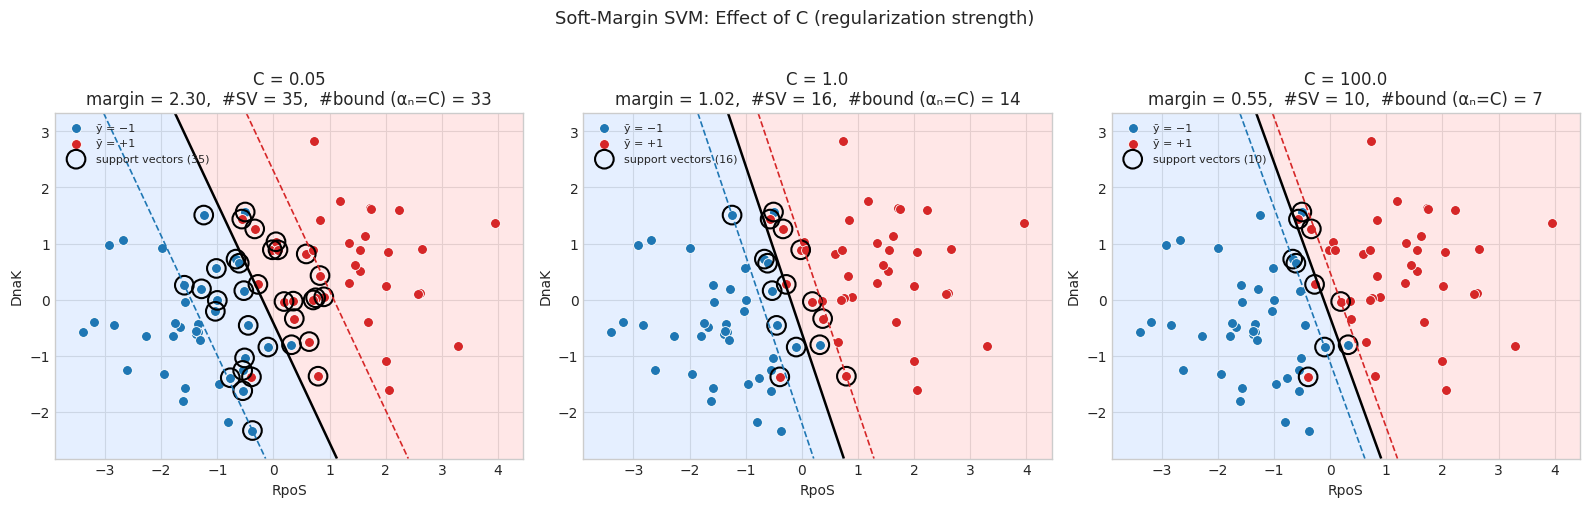

Smaller C → wider margin → more support vectors (and more violations)
Larger C  → narrower margin → tries hard to classify everything


In [6]:
def make_overlapping_data(n_per_class=40, seed=0):
    rng = np.random.RandomState(seed)
    X_neg = rng.randn(n_per_class, 2) * 0.9 + np.array([-1.0, -0.5])
    X_pos = rng.randn(n_per_class, 2) * 0.9 + np.array([ 1.0,  0.5])
    X = np.vstack([X_neg, X_pos])
    y = np.concatenate([-np.ones(n_per_class), np.ones(n_per_class)])
    perm = rng.permutation(len(y))
    return X[perm], y[perm]


X_soft, y_soft = make_overlapping_data(n_per_class=40, seed=2)

# Try several values of C
C_values = [0.05, 1.0, 100.0]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, C in zip(axes, C_values):
    res = solve_svm_dual(X_soft, y_soft, C=C)
    w_C, w0_C = res['w'], res['w0']
    sv_C = res['sv_idx']
    margin_w = 2 / np.linalg.norm(w_C)

    # Categorize SVs by alpha value
    on_margin = res['margin_mask']
    bound_alpha = (res['alpha'] >= C - 1e-5)
    n_violators = bound_alpha.sum()

    plot_decision_boundary(X_soft, y_soft,
                            lambda g, w=w_C, b=w0_C: linear_predict(g, w, b),
                            ax, sv_idx=sv_C,
                            title=f'C = {C}\n'
                                  f'margin = {margin_w:.2f},  '
                                  f'#SV = {len(sv_C)},  '
                                  f'#bound (αₙ=C) = {n_violators}')

plt.suptitle('Soft-Margin SVM: Effect of C (regularization strength)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Smaller C → wider margin → more support vectors (and more violations)')
print('Larger C  → narrower margin → tries hard to classify everything')

## 6. The Slack Variables $\xi_n$ Visualized

For each training point, $\xi_n = \max(0, 1 - \tilde y_n f_n)$ measures how much the margin constraint is violated:

- $\xi_n = 0$: point is at or beyond the margin (correctly classified with margin $\geq 1$)
- $0 < \xi_n < 1$: inside margin, but on correct side of decision boundary
- $\xi_n \geq 1$: on wrong side of decision boundary (misclassified)

$\sum_n \xi_n$ is an upper bound on the number of misclassified points.

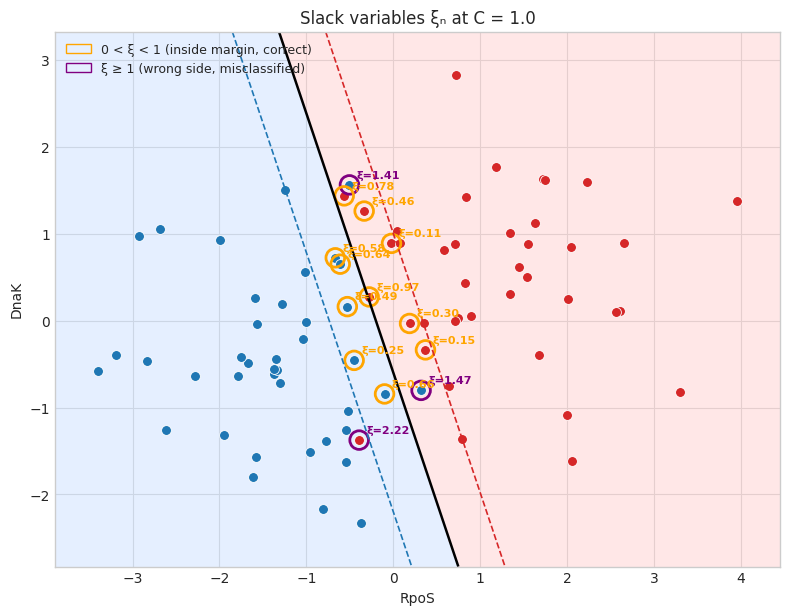

Total slack Σξ_n = 10.489
Misclassified: 3 (upper-bounded by Σξ_n: 10.49 ≥ 3)
Inside margin (correct): 13
Comfortably outside:     64


In [7]:
C = 1.0
res = solve_svm_dual(X_soft, y_soft, C=C)
w_C, w0_C = res['w'], res['w0']

# Compute slack: xi_n = max(0, 1 - y_n f_n)
f_n = X_soft @ w_C + w0_C
xi = np.maximum(0, 1 - y_soft * f_n)

# Categorize each point
correct_outside_margin = xi == 0
inside_margin_correct = (xi > 0) & (xi < 1)
wrong_side = xi >= 1

fig, ax = plt.subplots(figsize=(8, 6.5))
plot_decision_boundary(X_soft, y_soft,
                       lambda g: linear_predict(g, w_C, w0_C), ax,
                       sv_idx=None, title=f'Slack variables ξₙ at C = {C}')

# Overlay slack info
for i in np.where(xi > 1e-3)[0]:
    color = 'orange' if xi[i] < 1 else 'purple'
    ax.scatter(X_soft[i, 0], X_soft[i, 1], s=180, facecolors='none',
               edgecolors=color, linewidth=2)
    ax.annotate(f'ξ={xi[i]:.2f}', (X_soft[i, 0], X_soft[i, 1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, color=color, fontweight='bold')

# Custom legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='none', edgecolor='orange', label='0 < ξ < 1 (inside margin, correct)'),
    Patch(facecolor='none', edgecolor='purple', label='ξ ≥ 1 (wrong side, misclassified)'),
], loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Total slack Σξ_n = {xi.sum():.3f}')
print(f'Misclassified: {wrong_side.sum()} (upper-bounded by Σξ_n: {xi.sum():.2f} ≥ {wrong_side.sum()})')
print(f'Inside margin (correct): {inside_margin_correct.sum()}')
print(f'Comfortably outside:     {correct_outside_margin.sum()}')

## 7. The Kernel Trick (§17.3.4) — Nonlinear Boundaries

What if the data isn't linearly separable, even with slack? E.g., **circadian gene expression** where stressed cells form a *ring* around normal cells. The dual objective only ever uses $\mathbf{x}_i^\top \mathbf{x}_j$ — so we can replace it with any Mercer kernel:

$$\mathbf{x}_i^\top \mathbf{x}_j \;\longrightarrow\; \kappa(\mathbf{x}_i, \mathbf{x}_j)$$

The prediction becomes (Eq. 17.93):

$$f(\mathbf{x}) = \sum_{n \in \mathcal{S}} \alpha_n \tilde y_n\, \kappa(\mathbf{x}_n, \mathbf{x}) + \hat w_0$$

We never compute the (possibly infinite-dimensional) feature map $\boldsymbol{\phi}$ implied by the kernel.

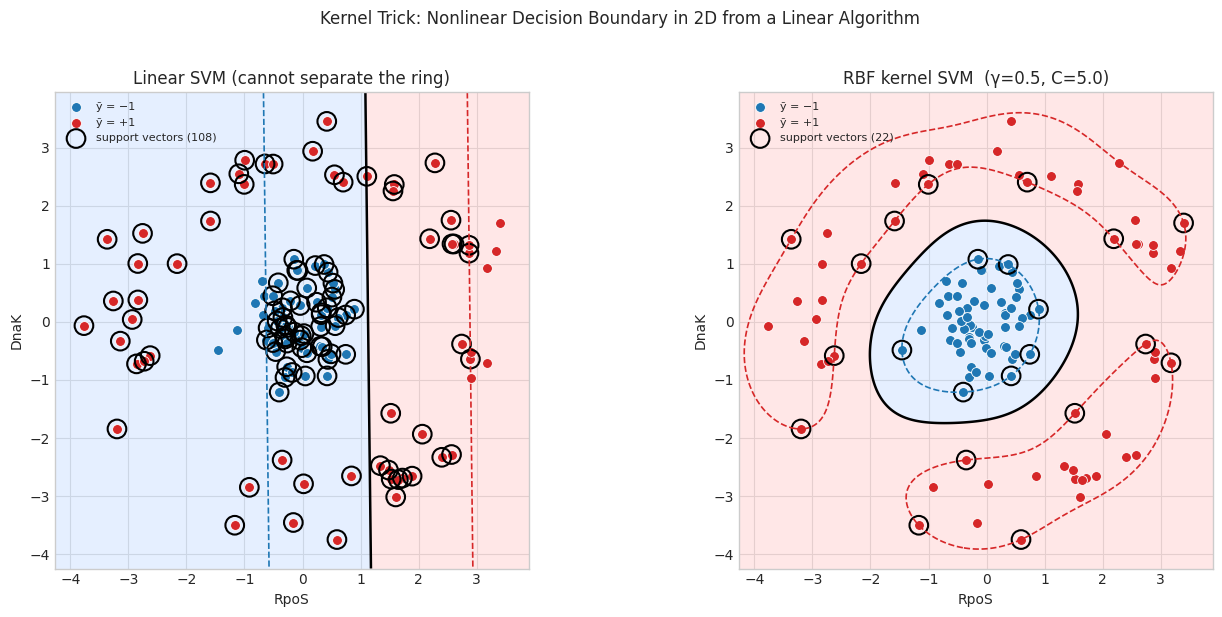

Linear SVM accuracy: 0.742
RBF SVM accuracy:    1.000
# RBF support vectors: 22 / 120


In [8]:
def make_ring_data(n=120, seed=0):
    """Stressed cells form a ring; normal cells in the center. Not linearly separable."""
    rng = np.random.RandomState(seed)
    n_inner = n // 2
    n_outer = n - n_inner
    # Inner cluster
    X_neg = rng.randn(n_inner, 2) * 0.5
    # Outer ring at radius ~3
    angles = rng.uniform(0, 2 * np.pi, n_outer)
    radii = 3.0 + rng.randn(n_outer) * 0.4
    X_pos = np.column_stack([radii * np.cos(angles), radii * np.sin(angles)])
    X = np.vstack([X_neg, X_pos])
    y = np.concatenate([-np.ones(n_inner), np.ones(n_outer)])
    perm = rng.permutation(len(y))
    return X[perm], y[perm]


def rbf_kernel(X1, X2, gamma=1.0):
    """RBF kernel: κ(x,x') = exp(-γ ||x-x'||²),  γ = 1/(2ℓ²)."""
    sq = cdist(X1, X2, metric='sqeuclidean')
    return np.exp(-gamma * sq)


X_ring, y_ring = make_ring_data(n=120, seed=3)

# Fit kernel SVM
gamma = 0.5
C_ring = 5.0
K_ring = rbf_kernel(X_ring, X_ring, gamma=gamma)
res_k = solve_svm_dual(X_ring, y_ring, C=C_ring, kernel_matrix=K_ring)
alpha_k, w0_k = res_k['alpha'], res_k['w0']
sv_idx_k = res_k['sv_idx']


def kernel_predict(grid, X_train, y_train, alpha, w0, gamma):
    """f(x*) = Σ α_n y_n κ(x_n, x*) + w0  (Eq. 17.93)."""
    K_test = rbf_kernel(grid, X_train, gamma=gamma)
    return K_test @ (alpha * y_train) + w0


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: linear SVM (will fail)
res_lin = solve_svm_dual(X_ring, y_ring, C=C_ring)
plot_decision_boundary(X_ring, y_ring,
                       lambda g: linear_predict(g, res_lin['w'], res_lin['w0']),
                       axes[0], sv_idx=res_lin['sv_idx'],
                       title='Linear SVM (cannot separate the ring)')

# Right: RBF kernel SVM
plot_decision_boundary(X_ring, y_ring,
                       lambda g: kernel_predict(g, X_ring, y_ring, alpha_k, w0_k, gamma),
                       axes[1], sv_idx=sv_idx_k,
                       title=f'RBF kernel SVM  (γ={gamma}, C={C_ring})')

plt.suptitle('Kernel Trick: Nonlinear Decision Boundary in 2D from a Linear Algorithm',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Accuracy
y_pred_lin = np.sign(linear_predict(X_ring, res_lin['w'], res_lin['w0']))
y_pred_k = np.sign(kernel_predict(X_ring, X_ring, y_ring, alpha_k, w0_k, gamma))
print(f'Linear SVM accuracy: {(y_pred_lin == y_ring).mean():.3f}')
print(f'RBF SVM accuracy:    {(y_pred_k == y_ring).mean():.3f}')
print(f'# RBF support vectors: {len(sv_idx_k)} / {len(y_ring)}')

## 8. Effect of $C$ and $\gamma$ (§17.3.8) — A 2D Grid

The two main hyperparameters of the RBF SVM are tightly coupled:
- $\gamma = 1/(2\ell^2)$: kernel **precision** — large $\gamma$ means narrow bumps (high variance, can overfit)
- $C$: regularization — large $C$ means few violations allowed (high variance)

The libsvm authors recommend a **log-spaced 2D grid** with $C \in \{2^{-5}, \ldots, 2^{15}\}$ and $\gamma \in \{2^{-15}, \ldots, 2^3\}$, evaluated by cross-validation.

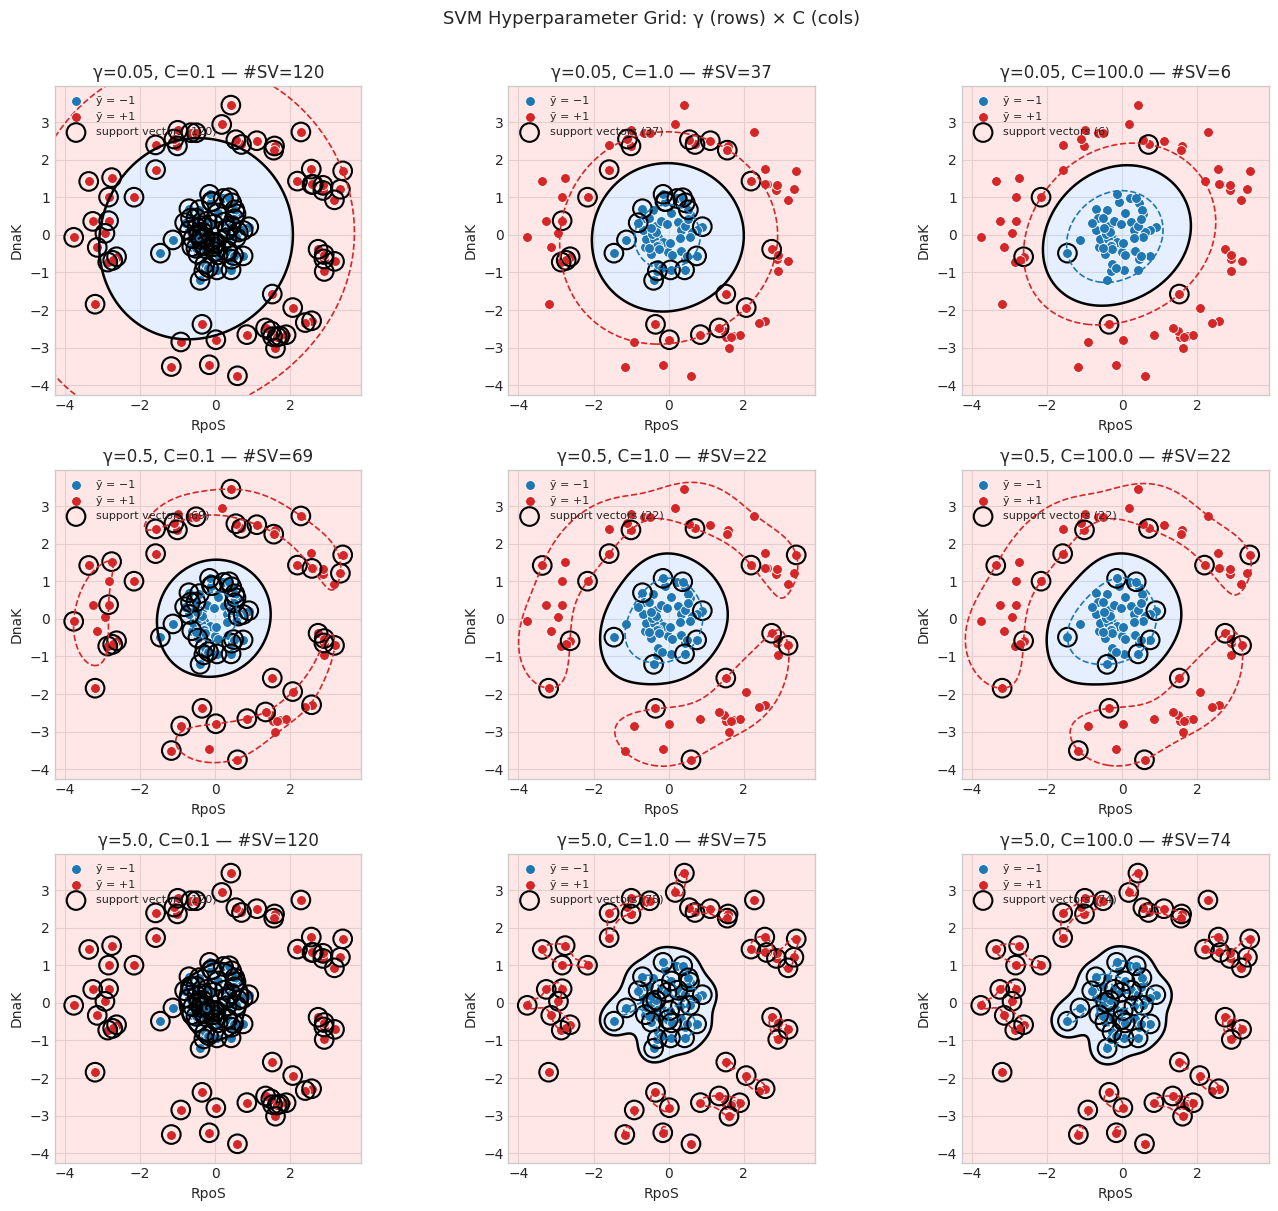

In [9]:
# Visualize the boundary across a small (C, gamma) grid on the ring data
gammas = [0.05, 0.5, 5.0]
Cs = [0.1, 1.0, 100.0]

fig, axes = plt.subplots(len(gammas), len(Cs), figsize=(14, 12))

for i, g in enumerate(gammas):
    for j, c in enumerate(Cs):
        K = rbf_kernel(X_ring, X_ring, gamma=g)
        res_ij = solve_svm_dual(X_ring, y_ring, C=c, kernel_matrix=K)
        ax = axes[i, j]
        plot_decision_boundary(
            X_ring, y_ring,
            lambda grid, K_train=X_ring, y_train=y_ring,
                   a=res_ij['alpha'], w0=res_ij['w0'], gg=g:
                   kernel_predict(grid, K_train, y_train, a, w0, gg),
            ax, sv_idx=res_ij['sv_idx'],
            title=f'γ={g}, C={c} — #SV={len(res_ij["sv_idx"])}')

plt.suptitle('SVM Hyperparameter Grid: γ (rows) × C (cols)', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

**Reading the grid**:
- *Top-left* ($\gamma$ small, $C$ small): underfit — boundary is too smooth and too forgiving
- *Top-right* ($\gamma$ small, $C$ large): smoother boundary forced through the data
- *Bottom-left* ($\gamma$ large, $C$ small): tight kernels but ignored
- *Bottom-right* ($\gamma$ large, $C$ large): overfit — boundary wraps around individual points

The "sweet spot" is somewhere in the middle. In practice, this is found via cross-validation.

## 9. Hinge Loss vs Logistic Loss (§17.3.6)

The soft-margin objective can be rewritten (Eq. 17.96) as ERM with the **hinge loss** plus an L2 regularizer:

$$L(\mathbf{w}) = \sum_{n} \ell_{\text{hinge}}(\tilde y_n, f_n) + \lambda \|\mathbf{w}\|^2, \quad \ell_{\text{hinge}}(\tilde y, \eta) = \max(0, 1 - \tilde y \eta)$$

This makes the connection to **logistic regression** explicit — both are convex upper bounds on the 0-1 loss, but:
- Hinge loss is **piecewise linear** with a **flat region** at $\tilde y \eta \geq 1$ → induces **sparse** $\boldsymbol{\alpha}$
- Log loss is **smooth** and *never zero* → all training points contribute to the gradient (no SVs)

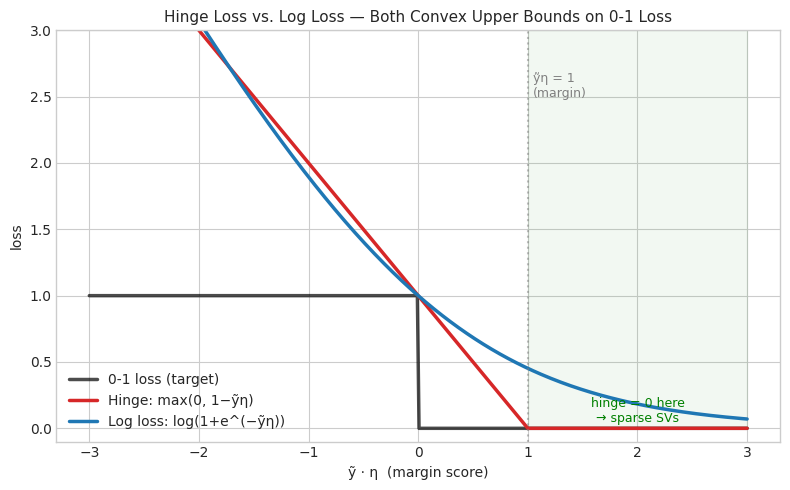

In [10]:
eta = np.linspace(-3, 3, 400)

zero_one = (eta < 0).astype(float)
hinge = np.maximum(0, 1 - eta)
log_loss = np.log(1 + np.exp(-eta)) / np.log(2)   # rescaled to share value at eta=0

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(eta, zero_one, 'k-', lw=2.5, label='0-1 loss (target)', alpha=0.7)
ax.plot(eta, hinge, '#d62728', lw=2.5, label='Hinge: max(0, 1−ỹη)')
ax.plot(eta, log_loss, '#1f77b4', lw=2.5, label='Log loss: log(1+e^(−ỹη))')

ax.axvline(1, color='gray', ls=':', alpha=0.5)
ax.text(1.05, 2.5, 'ỹη = 1\n(margin)', fontsize=9, color='gray')
ax.fill_between(eta, 0, 3, where=(eta >= 1), color='green', alpha=0.05)
ax.text(2, 0.05, 'hinge = 0 here\n→ sparse SVs', fontsize=9, color='green',
        ha='center')

ax.set_xlabel('ỹ · η  (margin score)')
ax.set_ylabel('loss')
ax.set_ylim(-0.1, 3)
ax.set_title('Hinge Loss vs. Log Loss — Both Convex Upper Bounds on 0-1 Loss', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 10. Platt Scaling (§17.3.5) — Probabilistic Outputs

SVMs produce a hard label $\hat y(\mathbf{x}) = \text{sign}(f(\mathbf{x}))$. To get a confidence score, **Platt scaling** fits a logistic transform on a held-out validation set:

$$p(y=1\mid \mathbf{x}) = \sigma(a\, f(\mathbf{x}) + b)$$

Importantly, $a$ and $b$ must be fit on a *separate* validation set — using the training set causes severe overfitting because $f$ already perfectly classifies it.

Platt parameters:  a = 42.713,  b = -8.330


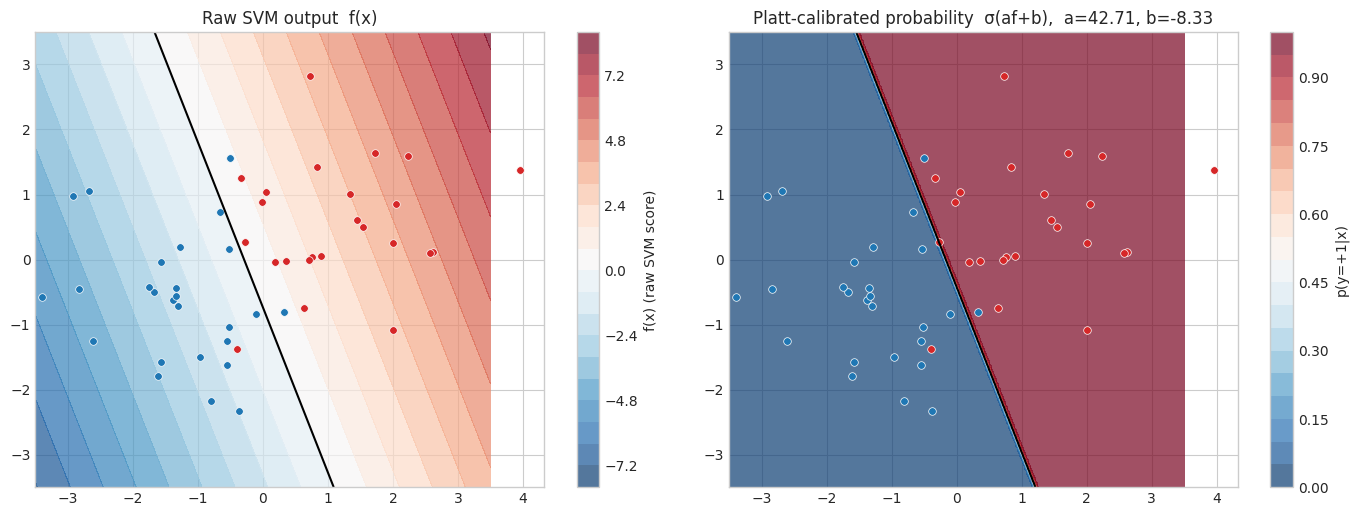

In [11]:
def platt_scale_fit(f_val, y_val):
    """Fit a, b in p(y=1|f) = σ(af + b) by maximum likelihood (gradient descent)."""
    # Convert y from {-1, +1} to {0, 1}
    t = (y_val + 1) / 2

    def neg_log_lik(params):
        a, b = params
        z = a * f_val + b
        # Numerically stable log(1 + exp(z))
        log1pexp = np.logaddexp(0, z)
        return float(np.sum(log1pexp - t * z))

    res = minimize(neg_log_lik, x0=[1.0, 0.0], method='L-BFGS-B')
    return res.x


# Use the soft-margin overlap data
X_tr, X_va = X_soft[:50], X_soft[50:]
y_tr, y_va = y_soft[:50], y_soft[50:]

res_tr = solve_svm_dual(X_tr, y_tr, C=1.0)
w_tr, w0_tr = res_tr['w'], res_tr['w0']

# SVM scores on validation set
f_va = X_va @ w_tr + w0_tr

# Fit Platt
a, b = platt_scale_fit(f_va, y_va)
print(f'Platt parameters:  a = {a:.3f},  b = {b:.3f}')

# Visualize on a grid
xx, yy = np.meshgrid(np.linspace(-3.5, 3.5, 200), np.linspace(-3.5, 3.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
f_grid = grid @ w_tr + w0_tr
p_grid = 1 / (1 + np.exp(-(a * f_grid + b)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw SVM score
ax = axes[0]
cs = ax.contourf(xx, yy, f_grid.reshape(xx.shape), levels=20, cmap='RdBu_r', alpha=0.7)
ax.contour(xx, yy, f_grid.reshape(xx.shape), levels=[0], colors='black', linewidths=1.5)
ax.scatter(X_tr[y_tr == -1, 0], X_tr[y_tr == -1, 1], c='#1f77b4', s=30,
           edgecolor='white', linewidth=0.5)
ax.scatter(X_tr[y_tr == +1, 0], X_tr[y_tr == +1, 1], c='#d62728', s=30,
           edgecolor='white', linewidth=0.5)
plt.colorbar(cs, ax=ax, label='f(x) (raw SVM score)')
ax.set_title('Raw SVM output  f(x)')
ax.set_aspect('equal')

# Platt probability
ax = axes[1]
cs = ax.contourf(xx, yy, p_grid.reshape(xx.shape), levels=20, cmap='RdBu_r',
                  vmin=0, vmax=1, alpha=0.7)
ax.contour(xx, yy, p_grid.reshape(xx.shape), levels=[0.5], colors='black', linewidths=1.5)
ax.scatter(X_tr[y_tr == -1, 0], X_tr[y_tr == -1, 1], c='#1f77b4', s=30,
           edgecolor='white', linewidth=0.5)
ax.scatter(X_tr[y_tr == +1, 0], X_tr[y_tr == +1, 1], c='#d62728', s=30,
           edgecolor='white', linewidth=0.5)
plt.colorbar(cs, ax=ax, label='p(y=+1|x)')
ax.set_title(f'Platt-calibrated probability  σ(af+b),  a={a:.2f}, b={b:.2f}')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 11. Multi-Class SVM (§17.3.7) — One-vs-Rest

SVMs are inherently binary. For $C$ classes, the **one-vs-rest** approach trains $C$ binary classifiers (each class vs. all others) and predicts $\hat y = \arg\max_c f_c(\mathbf{x})$.

Watch out: the magnitudes of $f_c$ are not calibrated across classifiers, and the "all others" set creates class imbalance.

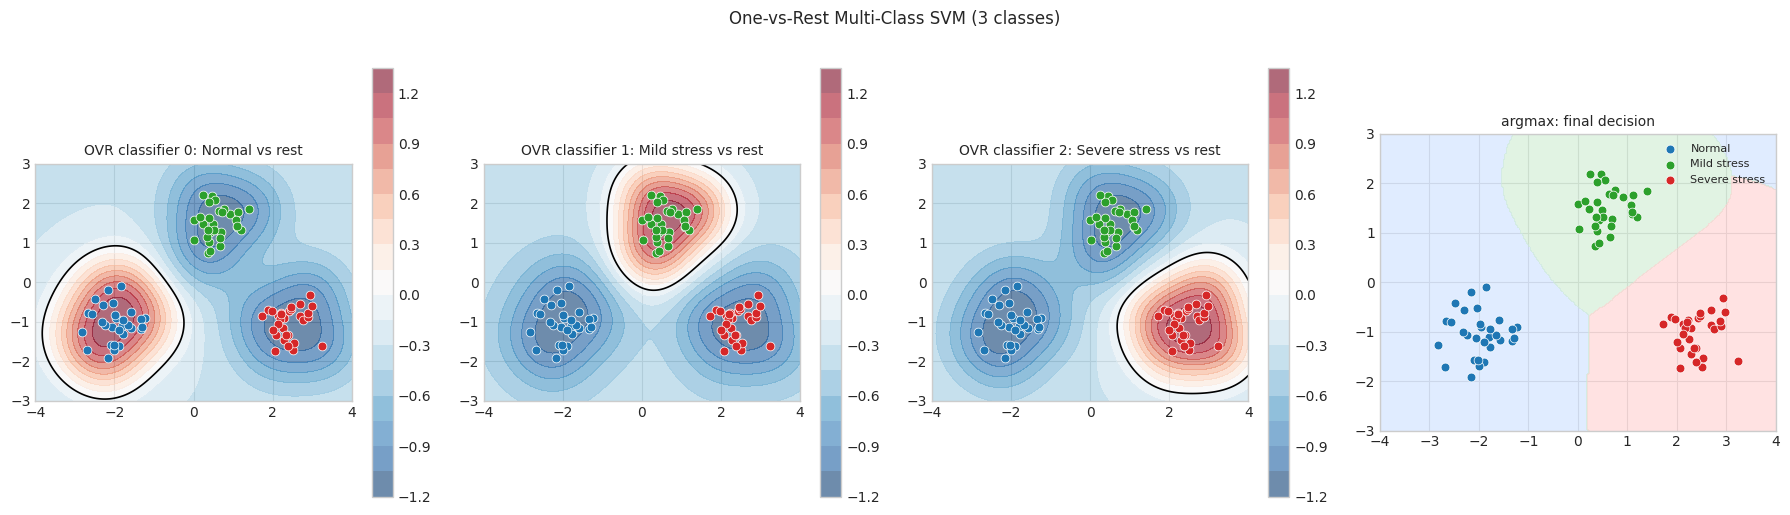

In [12]:
# Three cell types: normal, mildly stressed, severely stressed
def make_three_class(n_per=30, seed=0):
    rng = np.random.RandomState(seed)
    centers = np.array([[-2.0, -1.0], [0.5, 1.5], [2.5, -1.0]])
    X = np.vstack([rng.randn(n_per, 2) * 0.4 + c for c in centers])
    y = np.concatenate([np.full(n_per, c) for c in range(3)])
    perm = rng.permutation(len(y))
    return X[perm], y[perm]


X_mc, y_mc = make_three_class(n_per=30, seed=7)

# Fit one-vs-rest with RBF kernel
gamma_mc = 1.0
C_mc = 5.0
K_mc = rbf_kernel(X_mc, X_mc, gamma=gamma_mc)

classifiers = []
for c in range(3):
    y_binary = np.where(y_mc == c, 1.0, -1.0)
    res_c = solve_svm_dual(X_mc, y_binary, C=C_mc, kernel_matrix=K_mc)
    classifiers.append((res_c['alpha'], y_binary, res_c['w0']))


def multi_predict(grid, classifiers, X_train, gamma):
    """Return argmax of OVR scores."""
    scores = np.zeros((len(grid), len(classifiers)))
    K_test = rbf_kernel(grid, X_train, gamma=gamma)
    for c, (a, yb, b0) in enumerate(classifiers):
        scores[:, c] = K_test @ (a * yb) + b0
    return scores


xx, yy = np.meshgrid(np.linspace(-4, 4, 250), np.linspace(-3, 3, 250))
grid = np.c_[xx.ravel(), yy.ravel()]
scores = multi_predict(grid, classifiers, X_mc, gamma_mc)
predictions = np.argmax(scores, axis=1).reshape(xx.shape)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
class_colors = ['#1f77b4', '#2ca02c', '#d62728']
class_names = ['Normal', 'Mild stress', 'Severe stress']

# Per-class score maps
for c, ax in enumerate(axes[:3]):
    score_c = scores[:, c].reshape(xx.shape)
    cs = ax.contourf(xx, yy, score_c, levels=20, cmap='RdBu_r', alpha=0.6)
    ax.contour(xx, yy, score_c, levels=[0], colors='black', linewidths=1.2)
    for k in range(3):
        m = y_mc == k
        ax.scatter(X_mc[m, 0], X_mc[m, 1], c=class_colors[k], s=40,
                   edgecolor='white', linewidth=0.5)
    plt.colorbar(cs, ax=ax)
    ax.set_title(f'OVR classifier {c}: {class_names[c]} vs rest', fontsize=10)
    ax.set_aspect('equal')

# Final decision regions: argmax
ax = axes[3]
cmap_3 = ListedColormap(['#cce0ff', '#cdebd1', '#ffd0d0'])
ax.contourf(xx, yy, predictions, levels=[-0.5, 0.5, 1.5, 2.5], cmap=cmap_3, alpha=0.6)
for k in range(3):
    m = y_mc == k
    ax.scatter(X_mc[m, 0], X_mc[m, 1], c=class_colors[k], s=40,
               edgecolor='white', linewidth=0.5, label=class_names[k])
ax.set_title('argmax: final decision', fontsize=10)
ax.legend(fontsize=8)
ax.set_aspect('equal')

plt.suptitle('One-vs-Rest Multi-Class SVM (3 classes)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 12. SVM for Regression (§17.3.10) — $\epsilon$-Insensitive Loss

For regression, kernel ridge regression is dense (every $\alpha_n \neq 0$). To get a sparse solution, use the **$\epsilon$-insensitive loss** (Eq. 17.110):

$$L_\epsilon(y, \hat y) = \begin{cases} 0 & \text{if } |y - \hat y| < \epsilon \\ |y - \hat y| - \epsilon & \text{otherwise} \end{cases}$$

Points inside the **$\epsilon$-tube** around the prediction get *zero* loss → their dual variables vanish → only points *on or outside* the tube are support vectors.

Below we solve a small SVR primal directly with `scipy.optimize`.

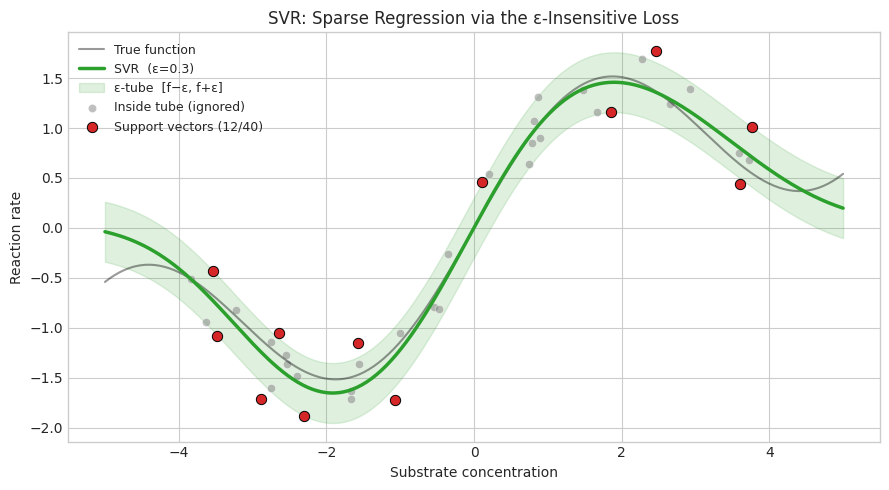

Total points: 40
Inside ε-tube (β ≈ 0): 28
Support vectors:       12
Sparsity: 70% of points are ignored


In [13]:
def fit_svr_primal_rbf(X, y, C=1.0, eps=0.1, gamma=1.0):
    """Fit kernel SVR by direct primal optimization with hinge-style ε-insensitive loss.

    Decision function: f(x) = Σ β_n κ(x_n, x) + b   (parameterize directly in β, b).
    Loss: Σ max(0, |y - f| - ε) + (1/(2C)) ||β||²_K  (β^T K β is the regularizer).
    """
    N = len(y)
    K = rbf_kernel(X, X, gamma=gamma)

    def loss(params):
        beta = params[:N]
        b = params[N]
        f = K @ beta + b
        residuals = np.maximum(0, np.abs(y - f) - eps)
        return float(0.5 * beta @ K @ beta + C * residuals.sum())

    res = minimize(loss, np.zeros(N + 1), method='L-BFGS-B',
                   options={'maxiter': 500})
    return res.x[:N], res.x[N], K


# Generate noisy 1D data: enzyme rate vs. substrate concentration
def true_fn(x):
    return np.sin(x) + 0.3 * x


N = 40
x_train = np.sort(np.random.uniform(-4, 4, N))
y_train = true_fn(x_train) + 0.3 * np.random.randn(N)

x_test = np.linspace(-5, 5, 300)

eps = 0.3
beta, b, K_train = fit_svr_primal_rbf(
    x_train.reshape(-1, 1), y_train, C=10.0, eps=eps, gamma=0.5
)
f_train = K_train @ beta + b
K_test = rbf_kernel(x_test.reshape(-1, 1), x_train.reshape(-1, 1), gamma=0.5)
f_test = K_test @ beta + b

# Identify support vectors: points outside the ε-tube
residuals = np.abs(y_train - f_train)
sv = residuals > eps - 1e-3

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_test, true_fn(x_test), 'k-', lw=1.5, alpha=0.4, label='True function')
ax.plot(x_test, f_test, '#2ca02c', lw=2.5, label=f'SVR  (ε={eps})')
ax.fill_between(x_test, f_test - eps, f_test + eps, alpha=0.15, color='#2ca02c',
                label=f'ε-tube  [f−ε, f+ε]')

ax.scatter(x_train[~sv], y_train[~sv], c='gray', s=35, alpha=0.5,
           edgecolor='white', linewidth=0.5, label='Inside tube (ignored)')
ax.scatter(x_train[sv], y_train[sv], c='#d62728', s=55,
           edgecolor='black', linewidth=0.7, label=f'Support vectors ({sv.sum()}/{N})')

ax.set_xlabel('Substrate concentration')
ax.set_ylabel('Reaction rate')
ax.set_title('SVR: Sparse Regression via the ε-Insensitive Loss')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

print(f'Total points: {N}')
print(f'Inside ε-tube (β ≈ 0): {(~sv).sum()}')
print(f'Support vectors:       {sv.sum()}')
print(f'Sparsity: {(~sv).sum()/N:.0%} of points are ignored')

## 13. Summary

| Concept | Key equation | Insight |
|---|---|---|
| **Large margin** (17.3.1) | $\min \tfrac{1}{2}\|\mathbf{w}\|^2$ s.t. $\tilde y_n f_n \geq 1$ | Robust boundary far from data |
| **Dual problem** (17.3.2) | $\max \sum \alpha_n - \tfrac12 \sum \alpha_i\alpha_j \tilde y_i \tilde y_j \mathbf{x}_i^\top\mathbf{x}_j$ | Only support vectors have $\alpha > 0$ |
| **Soft margin** (17.3.3) | Add $C \sum \xi_n$ | $0 \leq \alpha_n \leq C$; $C$ trades width vs. violations |
| **Kernel trick** (17.3.4) | $\mathbf{x}_i^\top \mathbf{x}_j \to \kappa(\mathbf{x}_i, \mathbf{x}_j)$ | Nonlinear boundaries; never compute $\phi$ |
| **Platt scaling** (17.3.5) | $p = \sigma(af + b)$ | Probabilistic output; fit on validation set |
| **Hinge loss** (17.3.6) | $\max(0, 1 - \tilde y\eta)$ | Flat region → sparse $\boldsymbol{\alpha}$ (vs. log loss) |
| **One-vs-rest** (17.3.7) | $\hat y = \arg\max_c f_c$ | Simple multi-class; uncalibrated scores |
| **Hyperparameters** (17.3.8) | Grid CV over $(C, \gamma)$ | Strongly coupled — search jointly |
| **SVR** (17.3.10) | $L_\epsilon = \max(0, |y-\hat y|-\epsilon)$ | Sparse regression — points inside $\epsilon$-tube vanish |

**The big picture**: SVMs trade probabilistic interpretation (which GPs and logistic regression provide) for **sparsity** and **convex optimization**. The kernel trick lets the same algorithm fit linear, polynomial, and RBF boundaries — making SVMs one of the most reusable classifiers ever invented.